Upload data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()
data = pd.read_csv('train.csv')
data = data.drop(columns=['Unnamed: 0'])

Saving train.csv to train.csv


In [ ]:
print(data.columns)
print(data)
print(data.head())

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density', 'Air.Quality'],
      dtype='object')
      Temperature  Humidity  PM2.5  PM10   NO2   SO2    CO  \
0            28.3      75.6    2.3  12.2  30.8   9.7  1.64   
1            23.1      74.7   26.7  33.8  24.4  12.6  1.63   
2            27.1      39.1    6.1   6.3  13.5   5.3  1.15   
3            26.5      70.7    6.9  16.0  21.9   5.6  1.01   
4            39.4      96.6   14.6  35.5  42.9  17.9  1.82   
...           ...       ...    ...   ...   ...   ...   ...   
3995         29.8      56.7    6.8  14.0  23.0   4.5  1.10   
3996         31.1      61.0   27.1  31.1  13.0   3.8  0.98   
3997         28.1      96.9    6.9  25.0  25.3  10.8  1.54   
3998         25.9      78.2   14.2  22.1  34.8   7.8  1.63   
3999         24.1      77.9   81.7  94.3  23.2  10.5  1.38   

      Proximity_to_Industrial_Areas  Population_Density Air.Quality  
0             

Preprocessing

In [ ]:
print(data.isnull().sum())
print(data.dtypes)

Temperature                      0
Humidity                         0
PM2.5                            0
PM10                             0
NO2                              0
SO2                              0
CO                               0
Proximity_to_Industrial_Areas    0
Population_Density               0
Air.Quality                      0
dtype: int64
Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air.Quality                       object
dtype: object


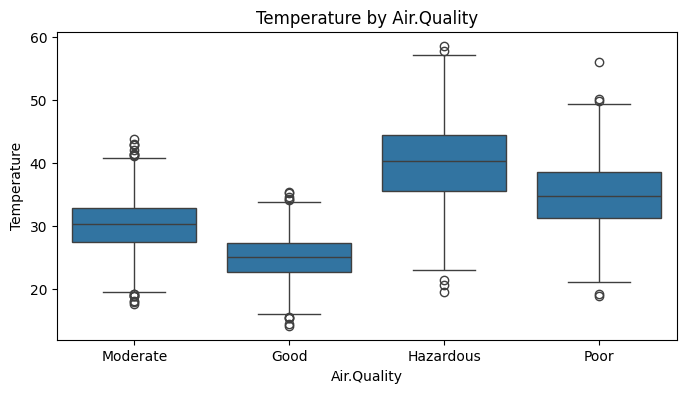

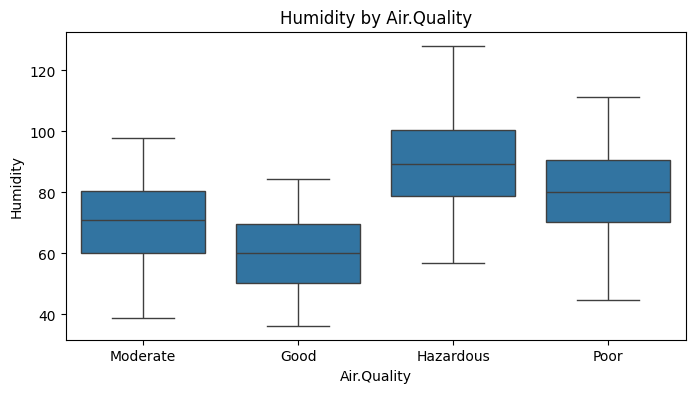

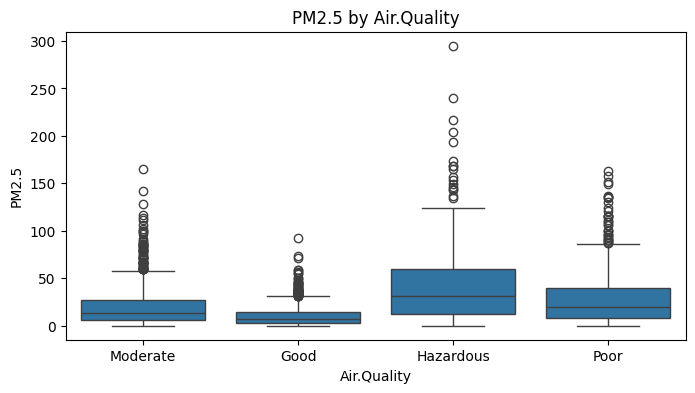

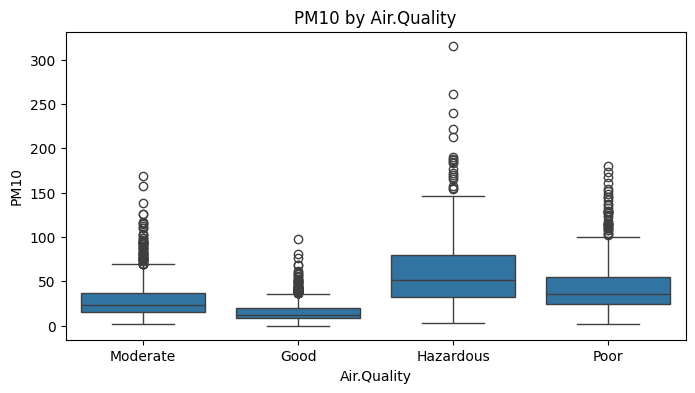

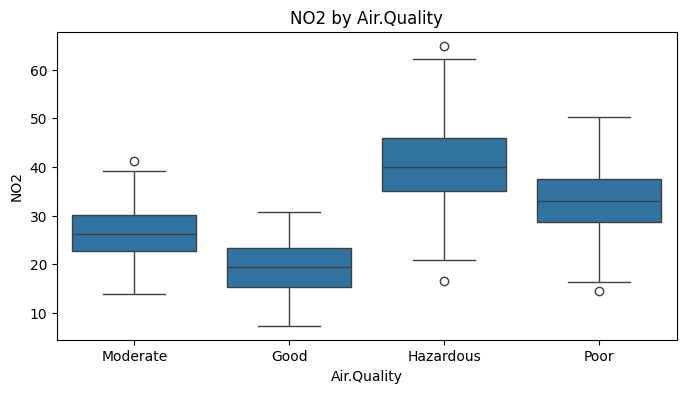

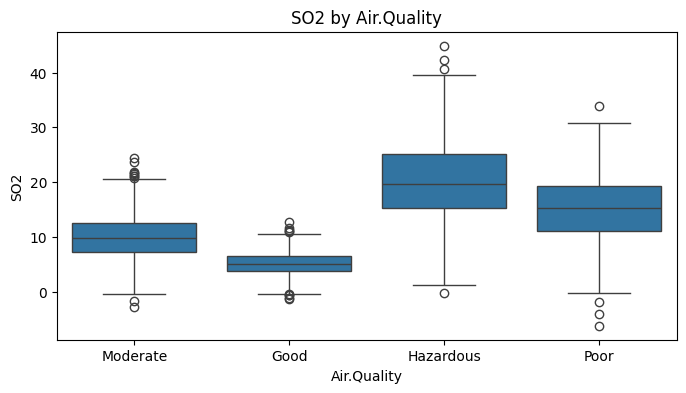

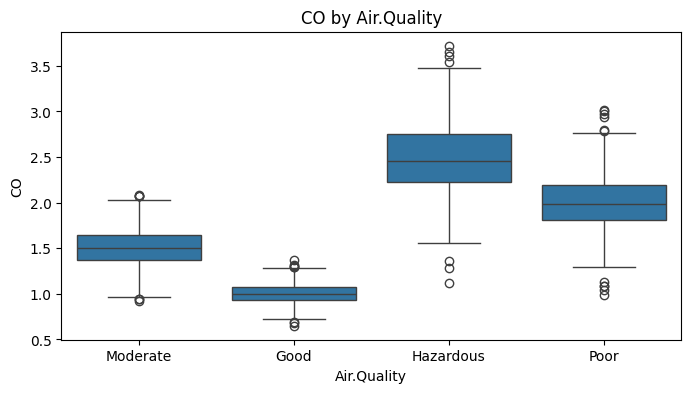

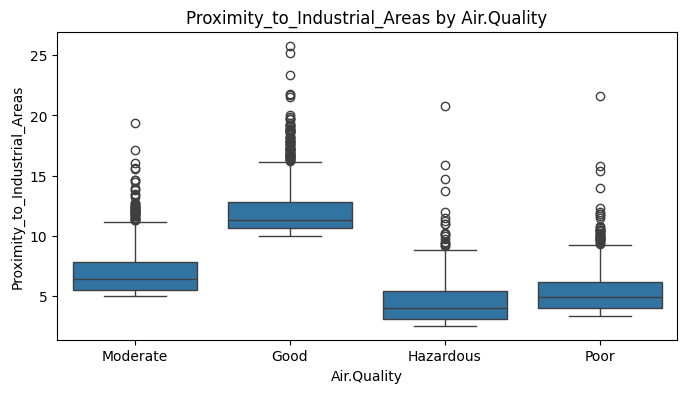

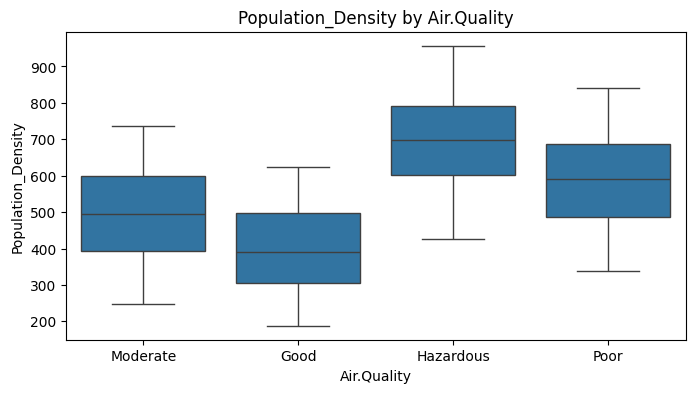

In [ ]:
numerical_cols = [
    'Temperature', 'Humidity', 'PM2.5',
    'PM10', 'NO2',
    'SO2', 'CO',
    'Proximity_to_Industrial_Areas', 'Population_Density'
]
response_col = 'Air.Quality'

import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=response_col, y=col, data=data)
    plt.title(f'{col} by {response_col}')
    plt.show()


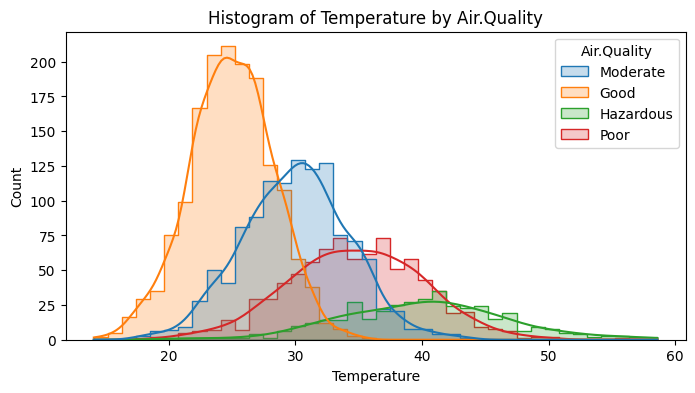

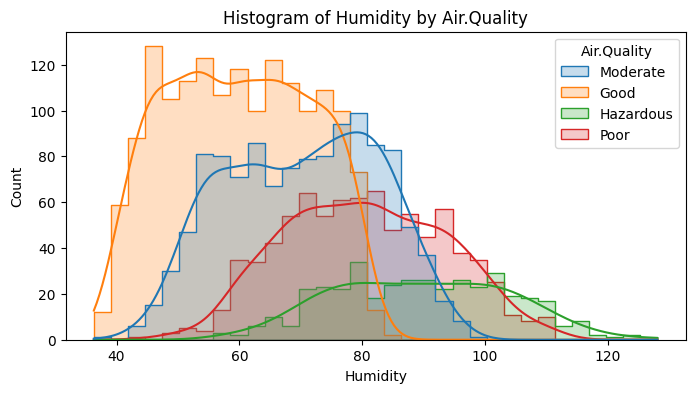

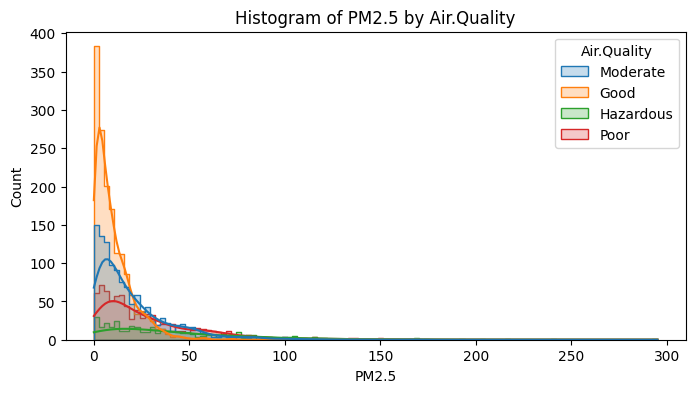

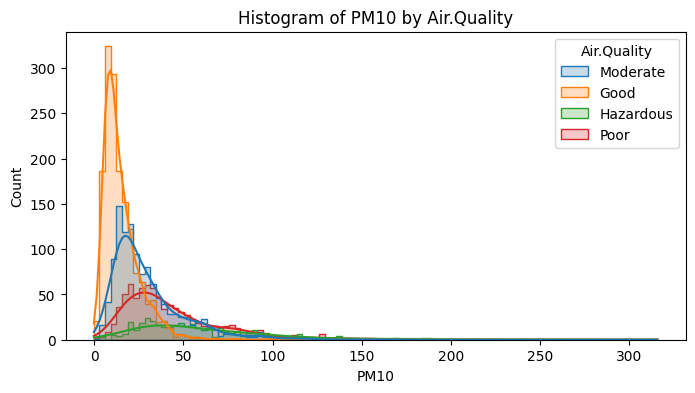

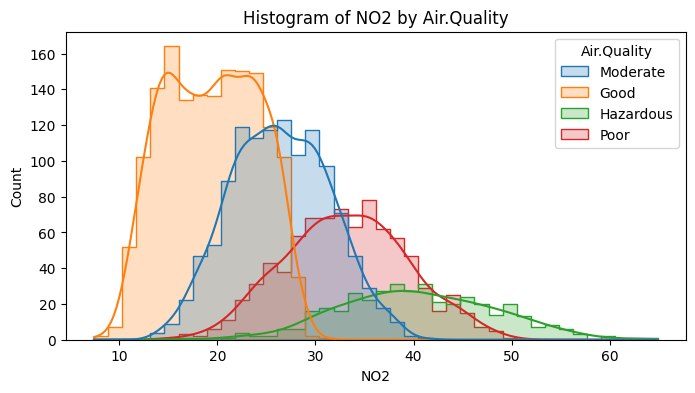

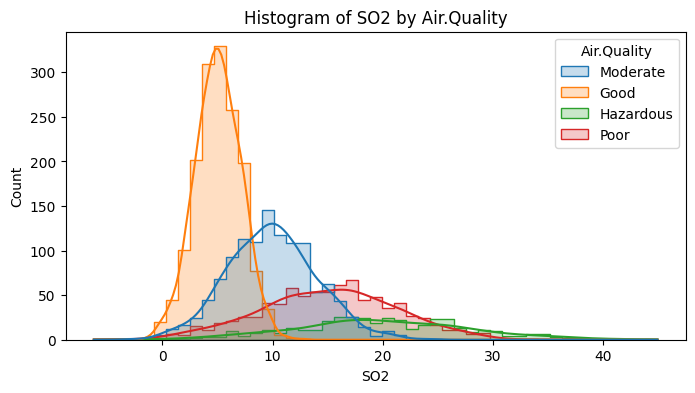

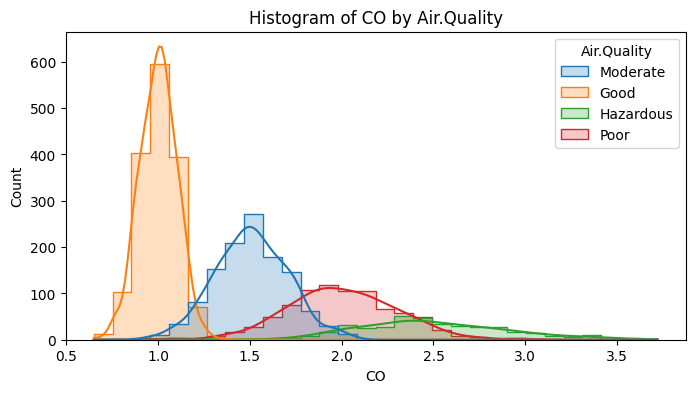

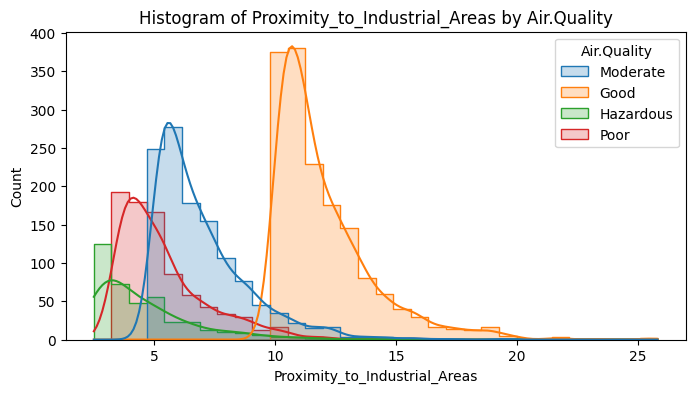

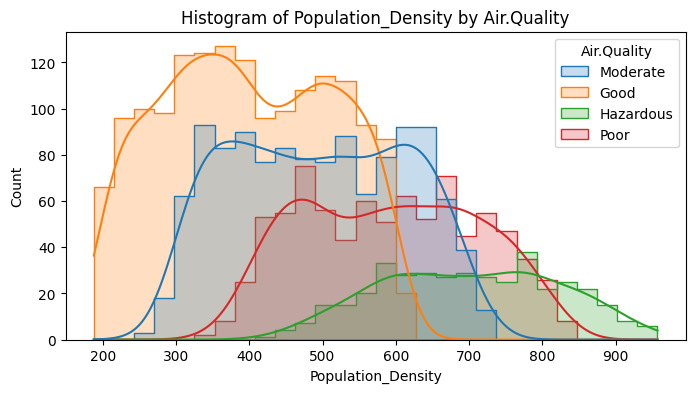

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data, x=col, hue=response_col, kde=True, element='step')
    plt.title(f'Histogram of {col} by {response_col}')
    plt.show()


In [ ]:
# Simple IQR-based outlier count
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < Q1 - 1.5 * IQR) | (data[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers detected")


Temperature: 52 outliers detected
Humidity: 14 outliers detected
PM2.5: 291 outliers detected
PM10: 271 outliers detected
NO2: 60 outliers detected
SO2: 85 outliers detected
CO: 36 outliers detected
Proximity_to_Industrial_Areas: 10 outliers detected
Population_Density: 6 outliers detected


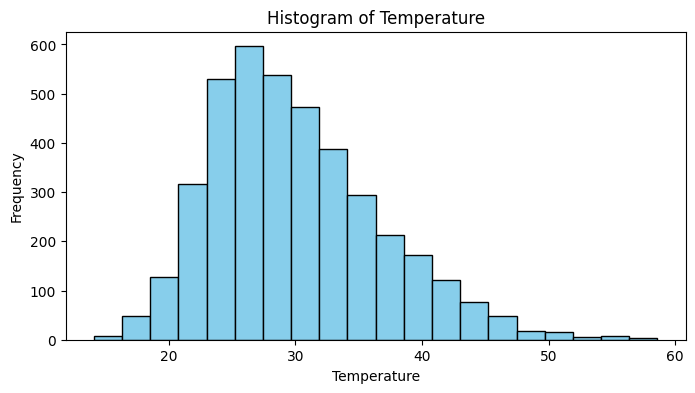

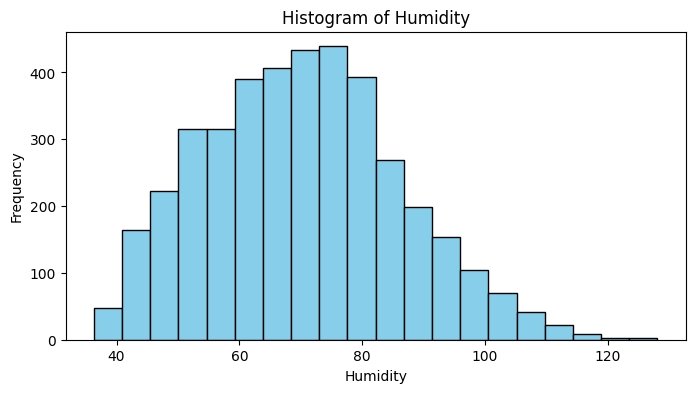

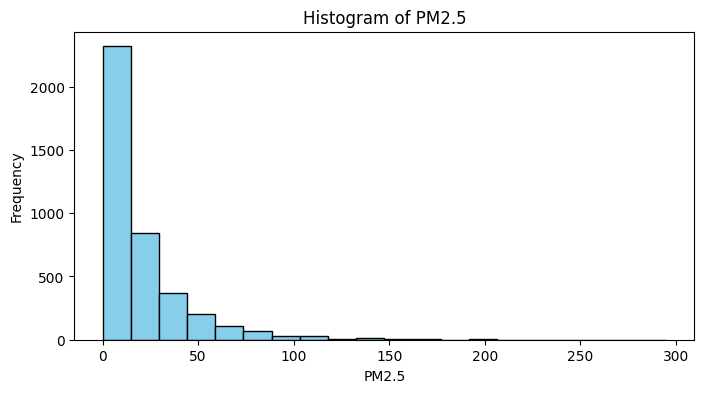

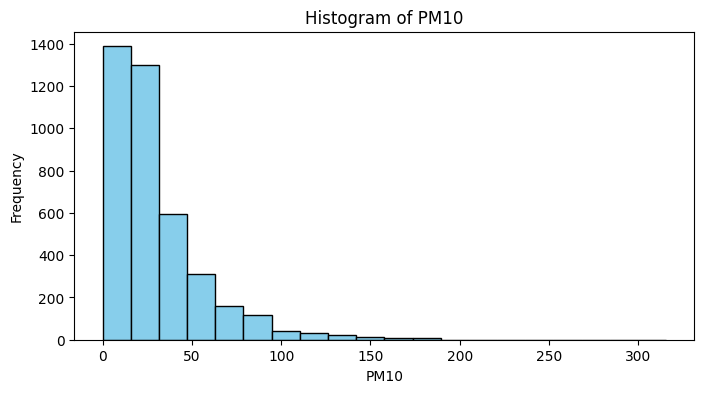

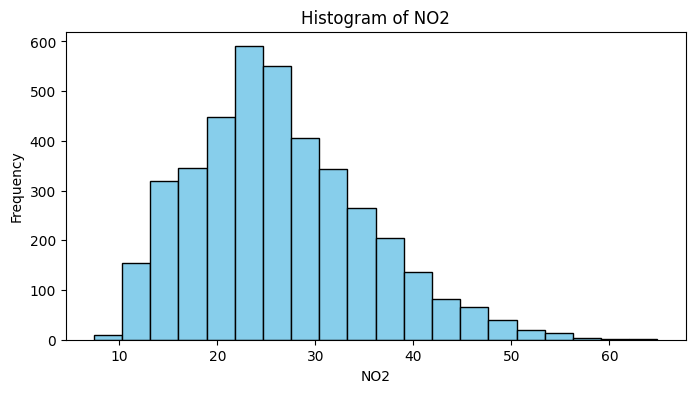

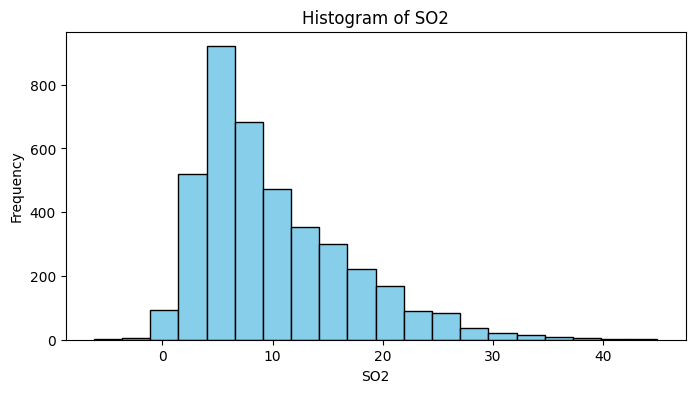

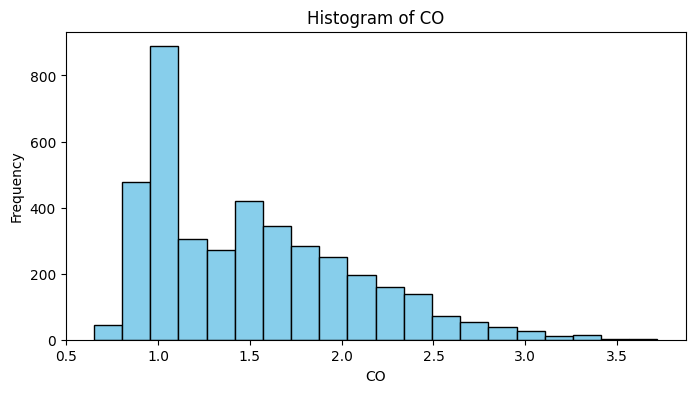

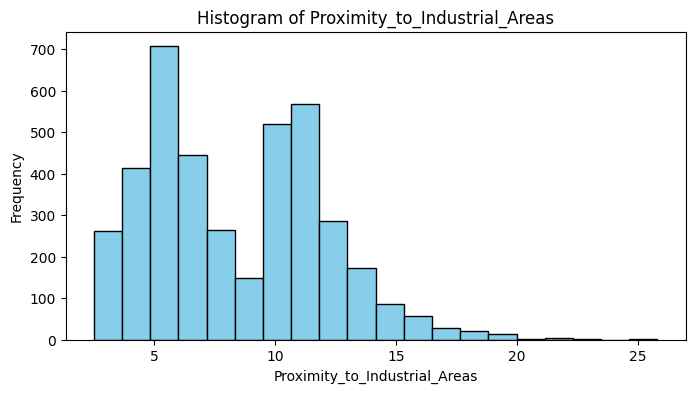

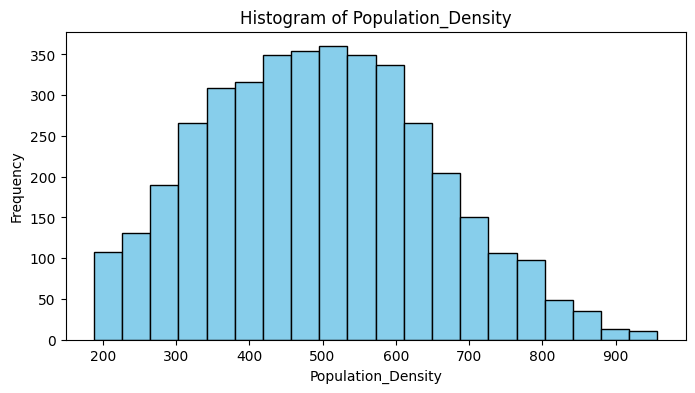

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    plt.hist(data[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [ ]:
!pip install phik



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.0/679.0 kB 2.6 MB/s eta 0:00:00


interval columns not set, guessing: ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']
                               Temperature  Humidity     PM2.5      PM10  \
Temperature                       1.000000  0.483188  0.378555  0.445179   
Humidity                          0.483188  1.000000  0.328731  0.395367   
PM2.5                             0.378555  0.328731  1.000000  0.985401   
PM10                              0.445179  0.395367  0.985401  1.000000   
NO2                               0.580212  0.496845  0.346694  0.437526   
SO2                               0.576989  0.537102  0.413347  0.479204   
CO                                0.677601  0.574666  0.435613  0.524045   
Proximity_to_Industrial_Areas     0.622431  0.522914  0.316754  0.434635   
Population_Density                0.496180  0.431259  0.285762  0.371472   
Air.Quality                       0.713093  0.606919  0.383288  0.497204   

       

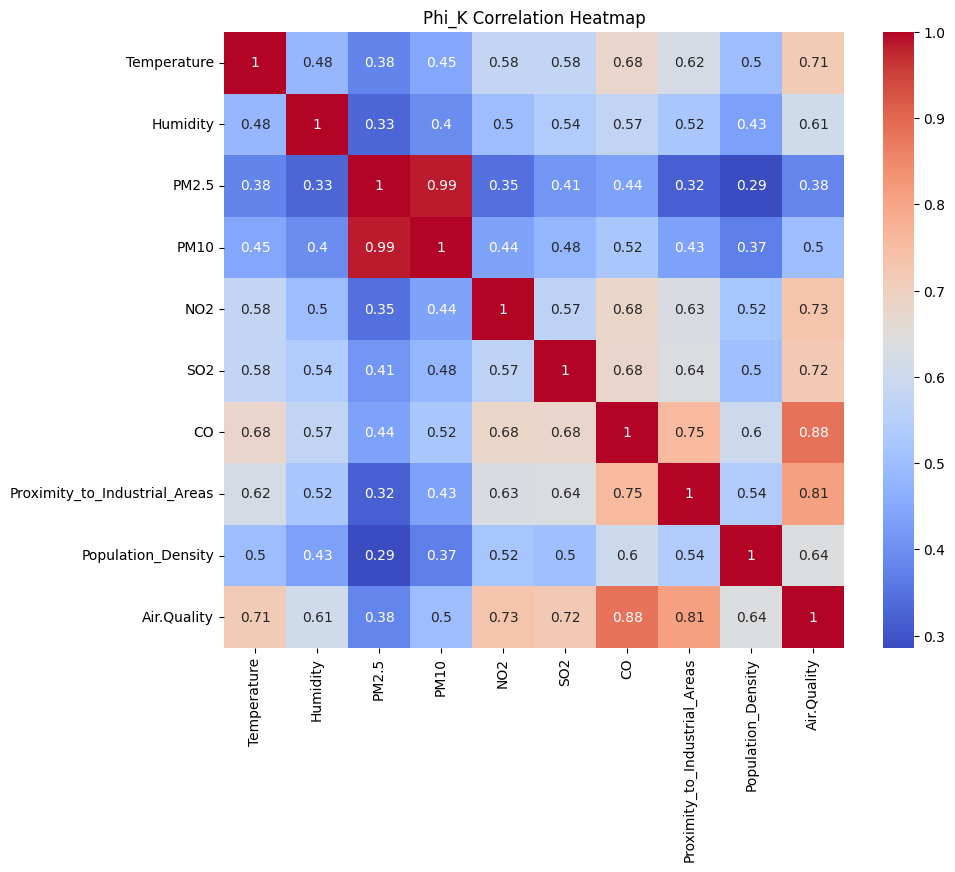

In [ ]:
import phik


phik_matrix = data.phik_matrix()
print(phik_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(phik_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Heatmap')
plt.show()


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


X = data[numerical_cols]
X = add_constant(X)

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


vif_data = vif_data[vif_data['Feature'] != 'const']

print(vif_data)


                         Feature        VIF
1                    Temperature   2.085547
2                       Humidity   1.580398
3                          PM2.5  28.706492
4                           PM10  33.650673
5                            NO2   2.253335
6                            SO2   2.027349
7                             CO   3.873047
8  Proximity_to_Industrial_Areas   2.281137
9             Population_Density   1.627177


In [ ]:
from scipy.stats import f_oneway

for col in numerical_cols:
    groups = [group[col].dropna().values for name, group in data.groupby(response_col)]
    stat, p = f_oneway(*groups)
    print(f'{col}: ANOVA p-value = {p:.4f}')


Temperature: ANOVA p-value = 0.0000
Humidity: ANOVA p-value = 0.0000
PM2.5: ANOVA p-value = 0.0000
PM10: ANOVA p-value = 0.0000
NO2: ANOVA p-value = 0.0000
SO2: ANOVA p-value = 0.0000
CO: ANOVA p-value = 0.0000
Proximity_to_Industrial_Areas: ANOVA p-value = 0.0000
Population_Density: ANOVA p-value = 0.0000


In [ ]:
from scipy.stats import shapiro

for col in numerical_cols:
    print(f'\nNormality test for {col}:')
    for group in data[response_col].unique():
        vals = data[data[response_col]==group][col].dropna()
        if len(vals) > 3:
            stat, p = shapiro(vals)
            print(f'  {group}: p-value = {p:.4f}')
        else:
            print(f'  {group}: Not enough data for test')




Normality test for Temperature:
  Moderate: p-value = 0.5456
  Good: p-value = 0.4762
  Hazardous: p-value = 0.4280
  Poor: p-value = 0.8028

Normality test for Humidity:
  Moderate: p-value = 0.0000
  Good: p-value = 0.0000
  Hazardous: p-value = 0.0045
  Poor: p-value = 0.0000

Normality test for PM2.5:
  Moderate: p-value = 0.0000
  Good: p-value = 0.0000
  Hazardous: p-value = 0.0000
  Poor: p-value = 0.0000

Normality test for PM10:
  Moderate: p-value = 0.0000
  Good: p-value = 0.0000
  Hazardous: p-value = 0.0000
  Poor: p-value = 0.0000

Normality test for NO2:
  Moderate: p-value = 0.0006
  Good: p-value = 0.0000
  Hazardous: p-value = 0.8066
  Poor: p-value = 0.1736

Normality test for SO2:
  Moderate: p-value = 0.1842
  Good: p-value = 0.8019
  Hazardous: p-value = 0.4638
  Poor: p-value = 0.6090

Normality test for CO:
  Moderate: p-value = 0.3263
  Good: p-value = 0.1930
  Hazardous: p-value = 0.0057
  Poor: p-value = 0.1579

Normality test for Proximity_to_Industrial_Are

In [ ]:
from scipy.stats import levene

levene_results = {}
for col in numerical_cols:
    groups = [group[col].dropna().values for name, group in data.groupby(response_col)]
    stat, p = levene(*groups, center='median')
    levene_results[col] = {'statistic': stat, 'p_value': p}

for var, res in levene_results.items():
    print(f"{var}: Levene's test statistic = {res['statistic']:.4f}, p-value = {res['p_value']:.4f}")


Temperature: Levene's test statistic = 124.3060, p-value = 0.0000
Humidity: Levene's test statistic = 10.7887, p-value = 0.0000
PM2.5: Levene's test statistic = 214.8600, p-value = 0.0000
PM10: Levene's test statistic = 222.6575, p-value = 0.0000
NO2: Levene's test statistic = 70.3982, p-value = 0.0000
SO2: Levene's test statistic = 437.2193, p-value = 0.0000
CO: Levene's test statistic = 431.7362, p-value = 0.0000
Proximity_to_Industrial_Areas: Levene's test statistic = 1.3589, p-value = 0.2535
Population_Density: Levene's test statistic = 1.3934, p-value = 0.2428


In [ ]:
!pip install scikit-posthocs


In [ ]:
import pandas as pd
from scipy.stats import kruskal

kruskal_results = {}

for col in numerical_cols:
    groups = [group[col].dropna().values for name, group in data.groupby(response_col)]
    stat, p = kruskal(*groups)
    kruskal_results[col] = {'statistic': stat, 'p_value': p}


for col, res in kruskal_results.items():
    print(f"{col}: H={res['statistic']:.4f}, p-value={res['p_value']:.4g}")


Temperature: H=2222.6656, p-value=0
Humidity: H=1481.6049, p-value=0
PM2.5: H=652.6347, p-value=3.909e-141
PM10: H=1594.3766, p-value=0
NO2: H=2423.4396, p-value=0
SO2: H=2235.4481, p-value=0
CO: H=3379.5770, p-value=0
Proximity_to_Industrial_Areas: H=2866.5172, p-value=0
Population_Density: H=1552.7180, p-value=0


In [ ]:
import scikit_posthocs as sp

dunn_results = {}
for col, res in kruskal_results.items():
    if res['p_value'] < 0.05:
        print(f"\nDunn's test for {col}:")
        dunn = sp.posthoc_dunn(data, val_col=col, group_col=response_col, p_adjust='bonferroni')
        print(dunn)
        dunn_results[col] = dunn



Dunn's test for Temperature:
                    Good      Hazardous       Moderate           Poor
Good        1.000000e+00  1.389002e-296  2.858128e-135  6.362259e-308
Hazardous  1.389002e-296   1.000000e+00   4.442502e-82   2.771113e-13
Moderate   2.858128e-135   4.442502e-82   1.000000e+00   3.817886e-47
Poor       6.362259e-308   2.771113e-13   3.817886e-47   1.000000e+00

Dunn's test for Humidity:
                    Good      Hazardous      Moderate           Poor
Good        1.000000e+00  1.351188e-206  1.344695e-71  1.284646e-201
Hazardous  1.351188e-206   1.000000e+00  1.260904e-70   2.013151e-11
Moderate    1.344695e-71   1.260904e-70  1.000000e+00   7.931630e-41
Poor       1.284646e-201   2.013151e-11  7.931630e-41   1.000000e+00

Dunn's test for PM2.5:
                   Good     Hazardous      Moderate          Poor
Good       1.000000e+00  1.940953e-90  5.224601e-42  3.135492e-88
Hazardous  1.940953e-90  1.000000e+00  2.976409e-25  2.632061e-05
Moderate   5.224601e-42  2

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


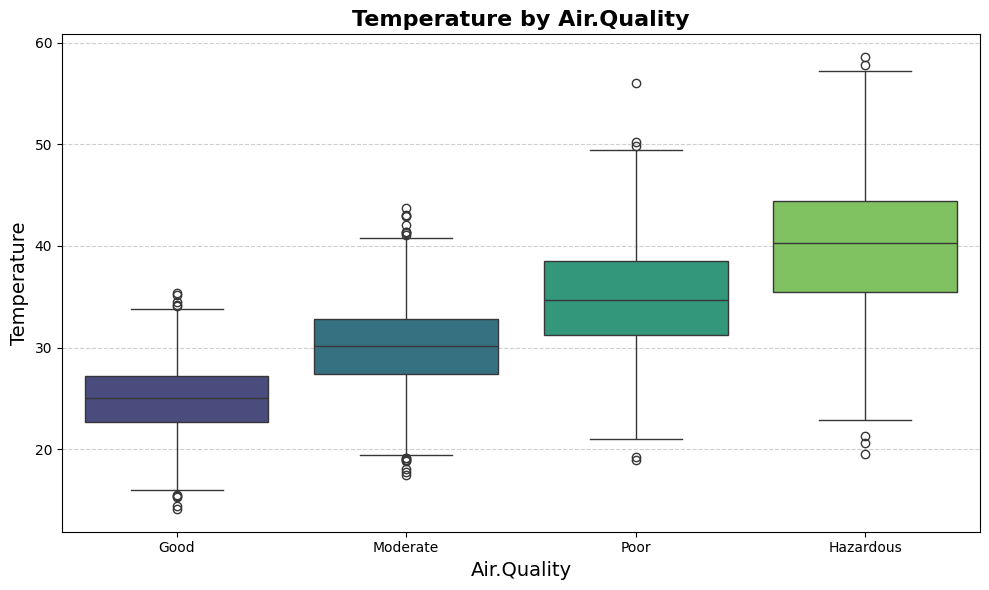

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


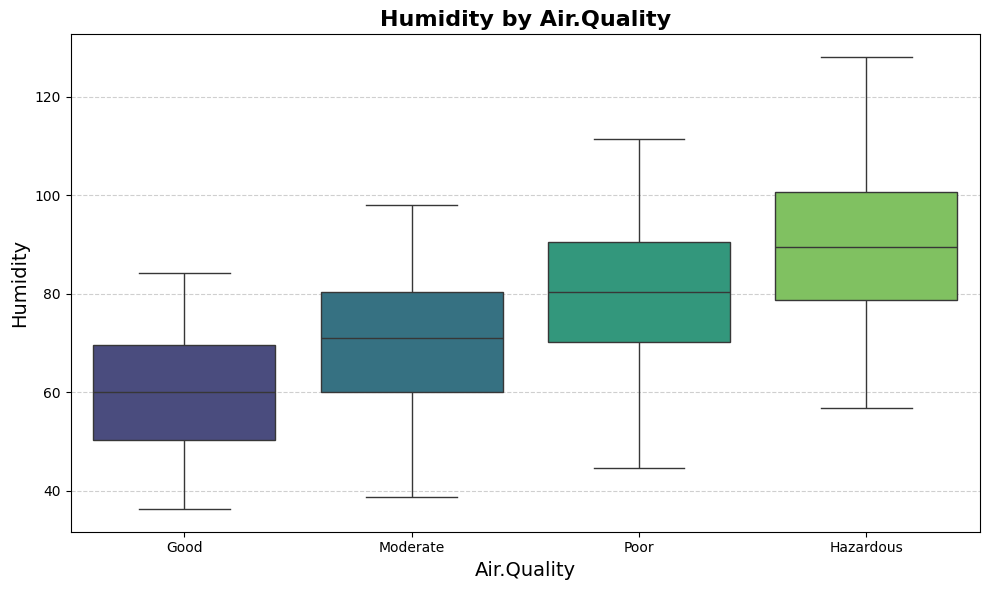

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


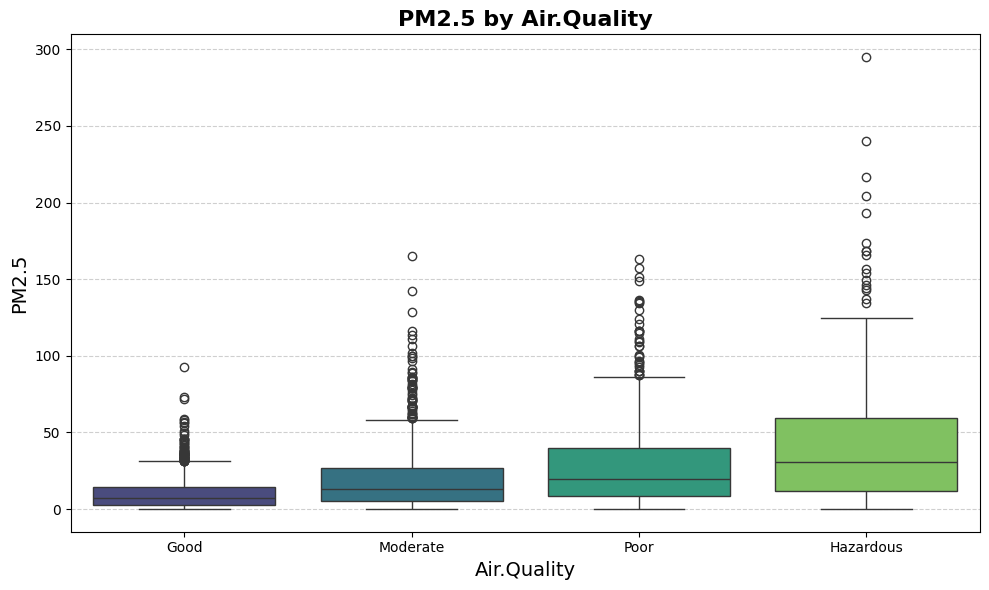

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


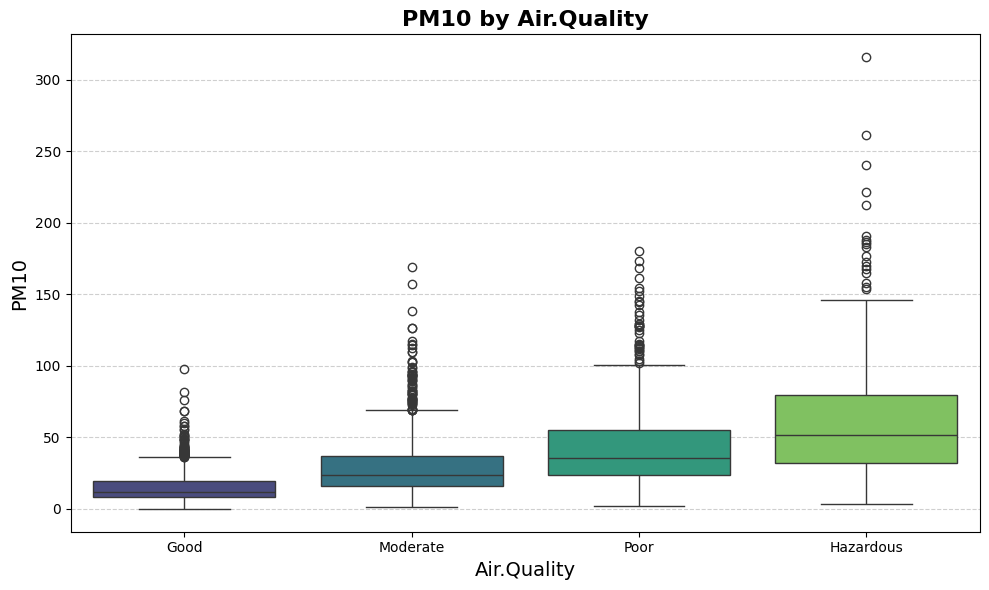

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


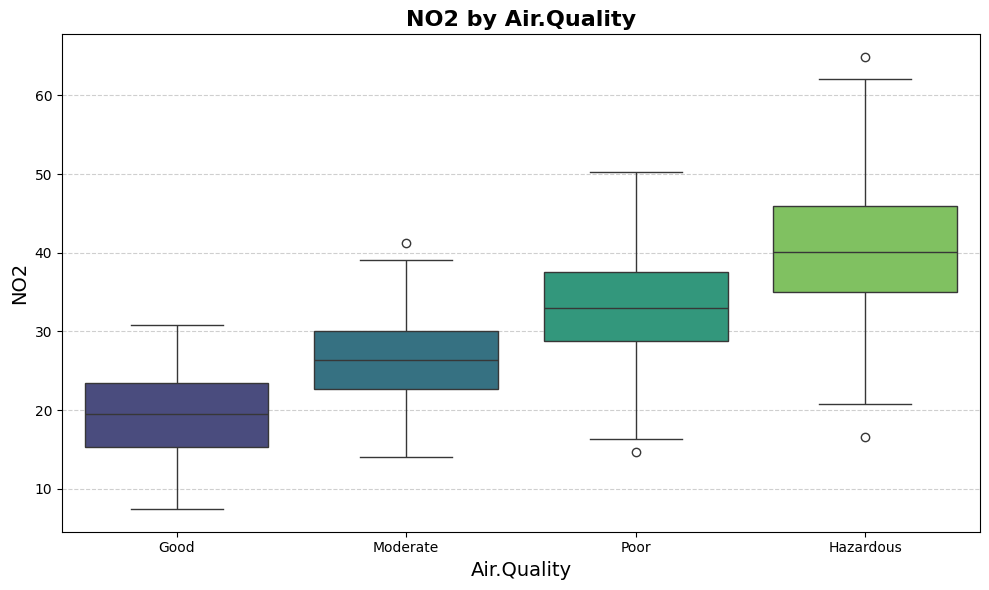

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


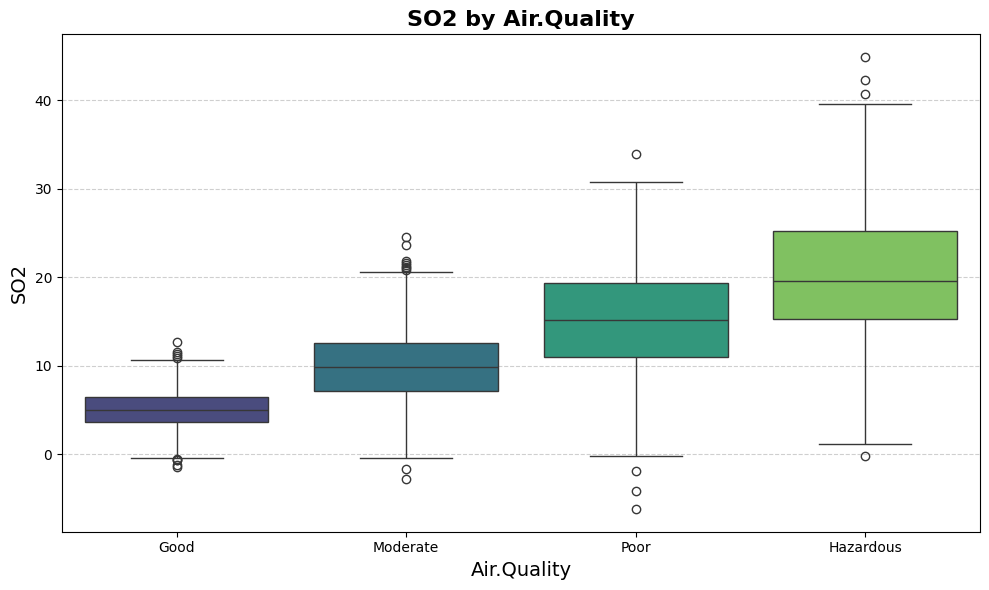

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


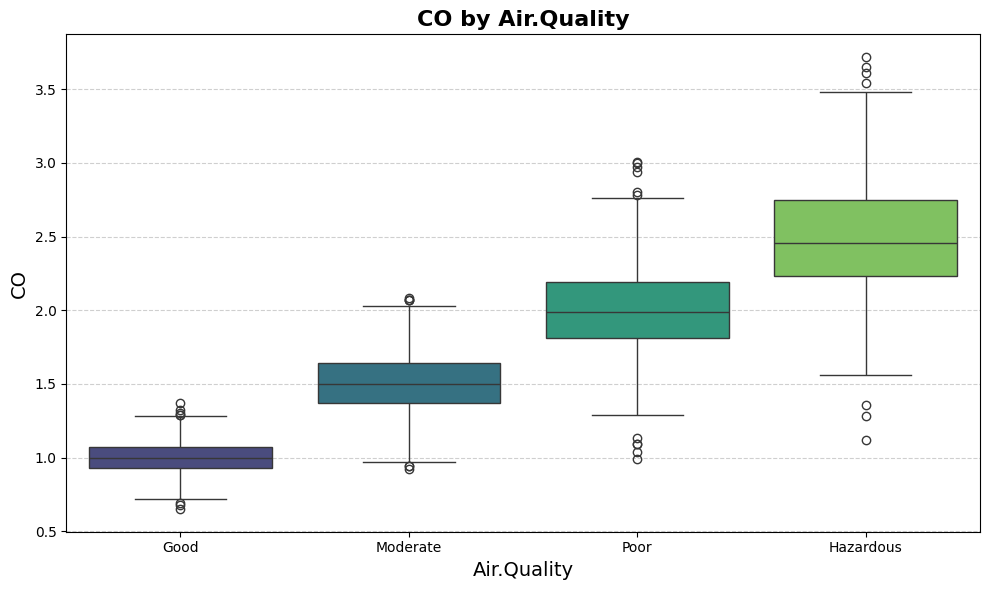

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


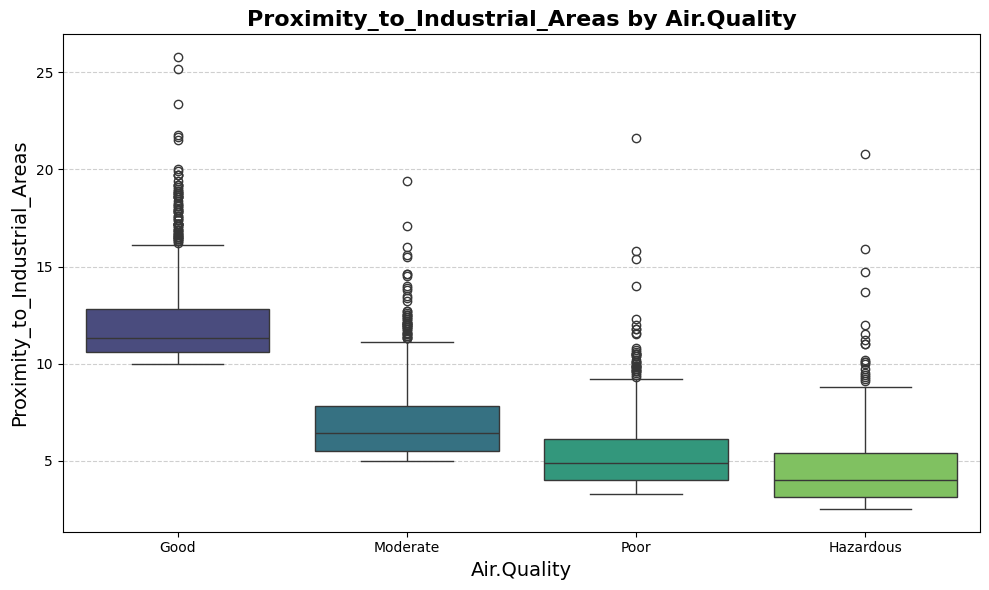

/tmp/ipython-input-18-3493793608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


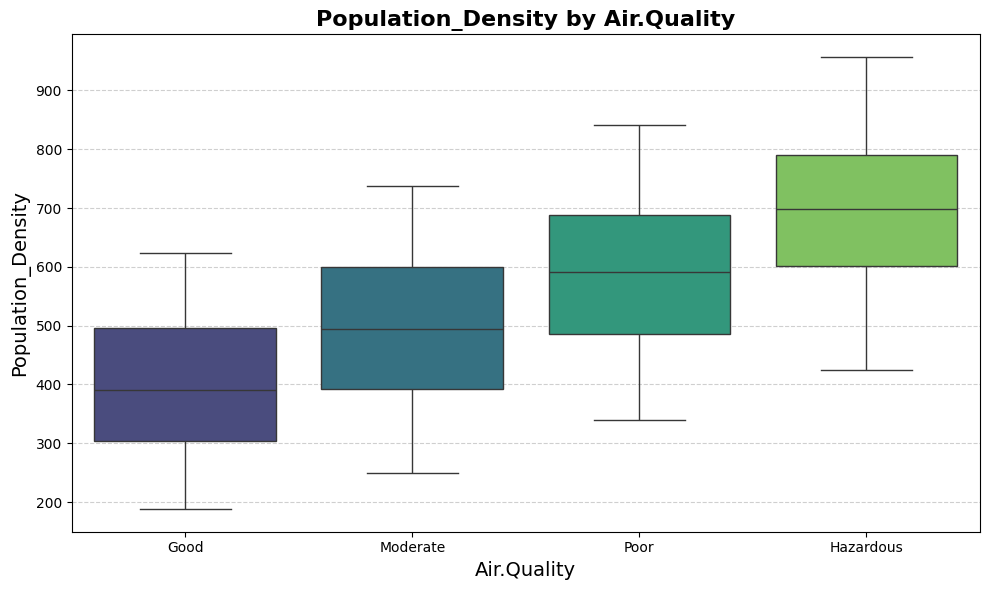

In [ ]:
order = ['Good', 'Moderate', 'Poor', 'Hazardous']

# Define a color palette
palette = sns.color_palette("viridis", len(order))

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        x=response_col,
        y=col,
        data=data,
        palette=palette,
        showfliers=True,
        order=order
    )
    plt.title(f'{col} by {response_col}', fontsize=16, fontweight='bold')
    plt.xlabel(response_col, fontsize=14)
    plt.ylabel(col, fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [ ]:
!pip install pingouin


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pingouin as pg

welch_results = {}
for col in numerical_cols:
    aov = pg.welch_anova(dv=col, between=response_col, data=data)
    welch_results[col] = aov
    print(f"Welch ANOVA for {col}:")
    print(aov)
    print()


Welch ANOVA for Temperature:
        Source  ddof1        ddof2            F  p-unc      np2
0  Air.Quality      3  1298.542607  1436.841501    0.0  0.55859

Welch ANOVA for Humidity:
        Source  ddof1        ddof2           F          p-unc       np2
0  Air.Quality      3  1394.845313  809.685553  8.287336e-305  0.393404

Welch ANOVA for PM2.5:
        Source  ddof1        ddof2           F          p-unc       np2
0  Air.Quality      3  1190.348488  245.187347  7.291893e-124  0.175674

Welch ANOVA for PM10:
        Source  ddof1        ddof2           F          p-unc       np2
0  Air.Quality      3  1190.277726  536.379037  1.880253e-220  0.309224

Welch ANOVA for NO2:
        Source  ddof1       ddof2            F  p-unc       np2
0  Air.Quality      3  1335.12253  1751.956194    0.0  0.613737

Welch ANOVA for SO2:
        Source  ddof1        ddof2            F  p-unc       np2
0  Air.Quality      3  1193.974536  1472.519964    0.0  0.548852

Welch ANOVA for CO:
        Source

In [ ]:
for col in numerical_cols:
    aov = pg.welch_anova(dv=col, between=response_col, data=data)
    if aov['p-unc'][0] < 0.05:
        print(f"Games-Howell post-hoc test for {col}:")
        posthoc = pg.pairwise_gameshowell(dv=col, between=response_col, data=data)
        print(posthoc)


Games-Howell post-hoc test for Temperature:
           A          B    mean(A)    mean(B)       diff        se          T  \
0       Good  Hazardous  24.967992  40.120455 -15.152462  0.339293 -44.658984   
1       Good   Moderate  24.967992  30.072208  -5.104216  0.147255 -34.662366   
2       Good       Poor  24.967992  34.771532  -9.803540  0.202714 -48.361319   
3  Hazardous   Moderate  40.120455  30.072208  10.048246  0.350588  28.661091   
4  Hazardous       Poor  40.120455  34.771532   5.348923  0.377255  14.178536   
5   Moderate       Poor  30.072208  34.771532  -4.699324  0.221102 -21.254133   

            df          pval    hedges  
0   446.893392  1.501022e-13 -3.635406  
1  2207.364653  0.000000e+00 -1.372968  
2  1173.691185  0.000000e+00 -2.380796  
3   506.845268  2.158274e-13  2.056367  
4   652.714015  1.424416e-13  0.930548  
5  1502.271957  0.000000e+00 -1.002296  
Games-Howell post-hoc test for Humidity:
           A          B    mean(A)    mean(B)       diff    

Feature columns:
['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Proximity_to_Industrial_Areas', 'Population_Density']
Shape of features: (4000, 9)

Original number of features: 9
Number of PCA components: 7
Variance explained by each component: [0.55478521 0.15169918 0.06558687 0.06225091 0.04935516 0.04680637
 0.04310078]
Cumulative variance explained: [0.55478521 0.70648439 0.77207126 0.83432217 0.88367733 0.9304837
 0.97358448]

Feature loadings for each principal component:
     Temperature  Humidity  PM2.5   PM10    NO2    SO2     CO  \
PC1        0.347     0.303  0.265  0.316  0.355  0.341  0.398   
PC2       -0.149    -0.135  0.685  0.601 -0.157 -0.175 -0.131   
PC3       -0.063     0.842 -0.008 -0.010 -0.056 -0.014 -0.044   
PC4       -0.273     0.416  0.018  0.003 -0.145 -0.265 -0.087   
PC5       -0.447    -0.021  0.015  0.013 -0.261  0.843 -0.016   
PC6        0.737     0.021  0.003 -0.010 -0.389  0.182 -0.046   
PC7       -0.072    -0.044 -0.003 -0.009  0

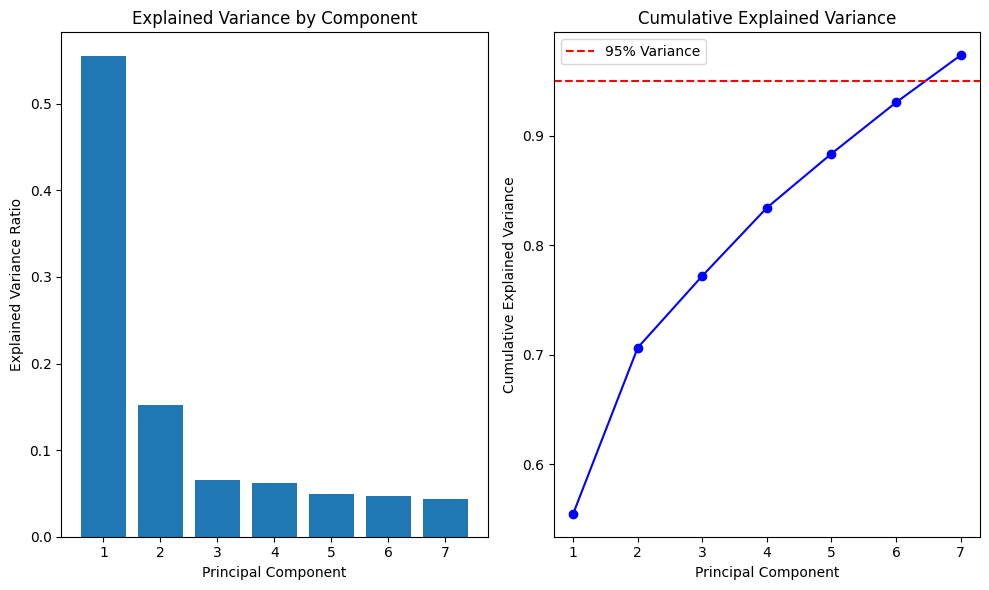


Final PCA dataset shape: (4000, 7)
PCA transformation completed successfully!


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np

X = data.drop('Air.Quality', axis=1)
y = data['Air.Quality']

print("Feature columns:")
print(X.columns.tolist())
print(f"Shape of features: {X.shape}")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to retain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"\nOriginal number of features: {X.shape[1]}")
print(f"Number of PCA components: {X_pca.shape[1]}")
print(f"Variance explained by each component: {pca.explained_variance_ratio_}")
print(f"Cumulative variance explained: {np.cumsum(pca.explained_variance_ratio_)}")

# Create a DataFrame with PCA components
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# Feature loadings
feature_names = X.columns
components_df = pd.DataFrame(
    pca.components_,
    columns=feature_names,
    index=pca_columns
)

print("\nFeature loadings for each principal component:")
print(components_df.round(3))

# Calculate how much each original variable is explained by the PCs
# This shows the proportion of each variable's variance explained by each PC
explained_variance_per_variable = pd.DataFrame(
    pca.components_**2 * pca.explained_variance_ratio_.reshape(-1, 1),
    columns=feature_names,
    index=pca_columns
)

print("\nVariance of each original variable explained by each PC:")
print(explained_variance_per_variable.round(3))

# Total variance explained for each original variable by all PCs
total_explained_per_variable = explained_variance_per_variable.sum(axis=0)
print("\nTotal variance explained for each original variable by all PCs:")
print(total_explained_per_variable.round(3))


print("\nMost important variables for each PC (absolute loadings > 0.3):")
for i, pc in enumerate(pca_columns):
    important_vars = components_df.loc[pc][abs(components_df.loc[pc]) > 0.3]
    if len(important_vars) > 0:
        print(f"\n{pc}:")
        for var, loading in important_vars.items():
            print(f"  {var}: {loading:.3f}")
    else:
        print(f"\n{pc}: No variables with |loading| > 0.3")


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Component')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'bo-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal PCA dataset shape: {X_pca_df.shape}")
print("PCA transformation completed successfully!")

In [ ]:
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]  # Creates ['PC1', ..., 'PC7']
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Assume `data` is your DataFrame with features and target 'Air.Quality'
# Replace this with your actual data loading code
# Example:
# data = pd.read_csv('your_data.csv')

X = data.drop('Air.Quality', axis=1)
y = data['Air.Quality']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA with 2 components for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame with PCs
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add Air.Quality target
X_pca_df['Air.Quality'] = y.values

# Ensure Air.Quality is integer type (important for mapping)
X_pca_df['Air.Quality'] = X_pca_df['Air.Quality'].astype(int)

# Define label mapping
label_map = {1: "Good", 2: "Moderate", 3: "Poor", 4: "Hazardous"}

# Map Air.Quality numeric to labels
X_pca_df['Air.Quality_Label'] = X_pca_df['Air.Quality'].map(label_map)

# Check if any NaN labels (should be zero)
nan_count = X_pca_df['Air.Quality_Label'].isna().sum()
if nan_count > 0:
    print(f"Warning: {nan_count} NaN labels found. Here are problematic rows:")
    print(X_pca_df.loc[X_pca_df['Air.Quality_Label'].isna()])

# Explained variance percentages for axis labels
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

# Plot PC1 vs PC2 colored by Air Quality class
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=X_pca_df,
    x='PC1', y='PC2',
    hue='Air.Quality_Label',
    palette='Set2',
    s=60,
    edgecolor='k',
    alpha=0.7
)

plt.title('PCA Projection: PC1 vs PC2', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pc1_var:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pc2_var:.1f}% Variance)')
plt.legend(title='Air Quality')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


ValueError: invalid literal for int() with base 10: 'Moderate'

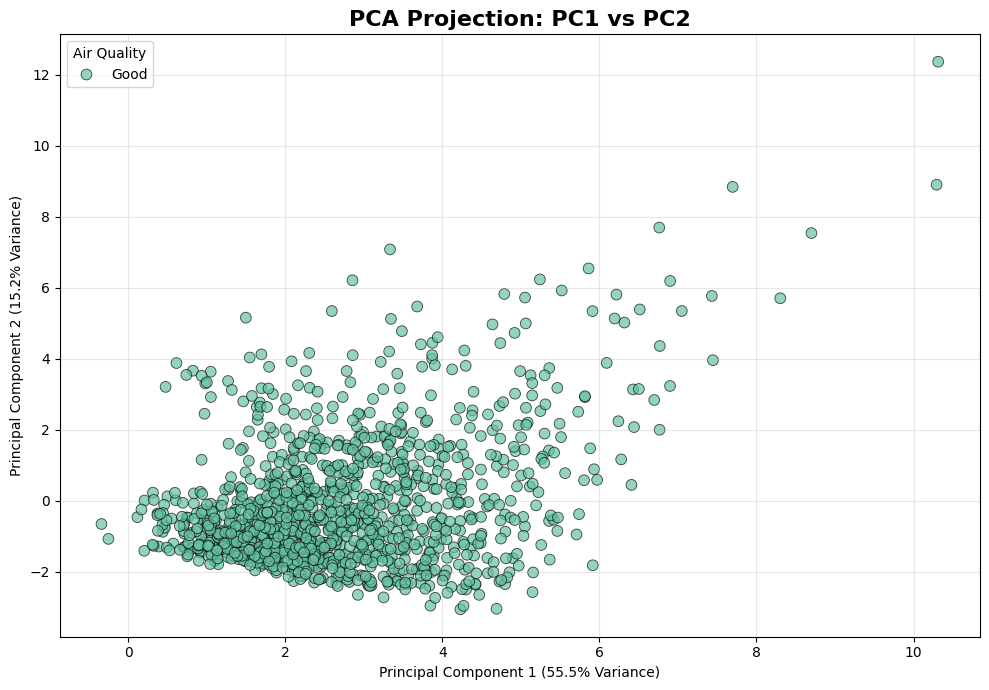

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you already have:
# X_pca_df with columns 'PC1', 'PC2', 'Air.Quality_Label'
# and pca.explained_variance_ratio_ from your PCA object

# Calculate % variance explained by PC1 and PC2
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=X_pca_df,
    x='PC1', y='PC2',
    hue='Air.Quality_Label',
    palette='Set2',
    s=60,
    edgecolor='k',
    alpha=0.7
)

plt.title('PCA Projection: PC1 vs PC2', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pc1_var:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pc2_var:.1f}% Variance)')
plt.legend(title='Air Quality')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


For n_clusters = 2, the average silhouette_score is: 0.3442
For n_clusters = 3, the average silhouette_score is: 0.2739
For n_clusters = 4, the average silhouette_score is: 0.2633
For n_clusters = 5, the average silhouette_score is: 0.2572

Best number of clusters based on silhouette score: 2

Cluster distribution:
cluster
0    2307
1    1693
Name: count, dtype: int64

Cluster centers (scaled data):
   Temperature  Humidity     PM2.5      PM10       NO2       SO2        CO  \
0    -0.558183 -0.507032 -0.368503 -0.457716 -0.576299 -0.551093 -0.646629   
1     0.760620  0.690917  0.502147  0.623715  0.785306  0.750958  0.881141   

   Proximity_to_Industrial_Areas  Population_Density  
0                       0.588732           -0.511379  
1                      -0.802247            0.696841  

Cluster centers (original scale):
   Temperature   Humidity      PM2.5       PM10        NO2        SO2  \
0    26.293888  62.168531  10.925618  17.601951  21.317339   6.348201   
1    35.096633  

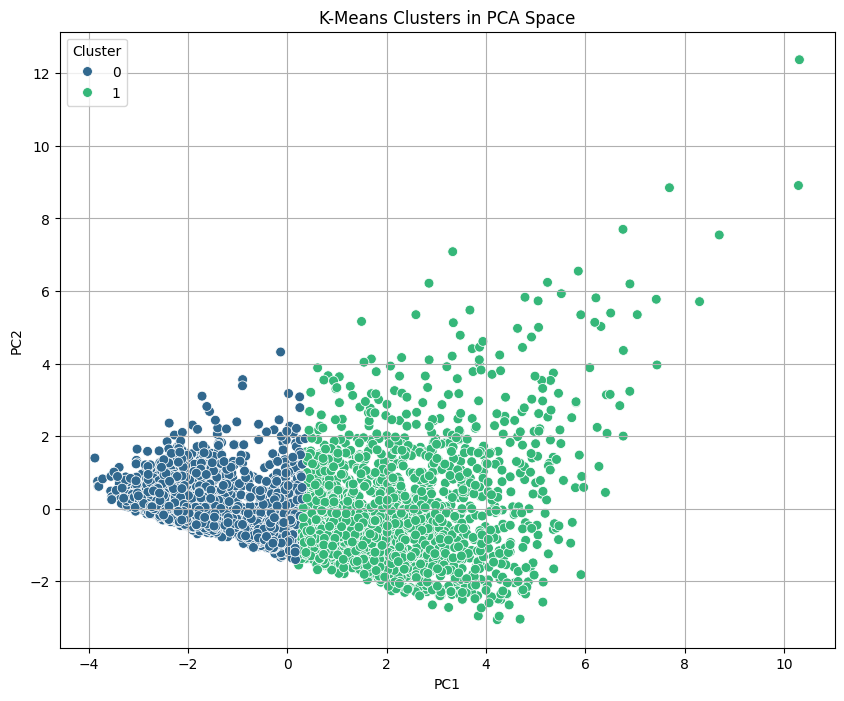


Cross-tabulation of Original Air.Quality and Clusters:
cluster         0    1
Air.Quality           
Good         1584    0
Hazardous       0  396
Moderate      710  481
Poor           13  816


In [ ]:

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


X_cluster = data[numerical_cols].copy()
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)


silhouette_scores = []
k_values = range(2, 6) # We expect around 4 clusters based on the response variable levels

for n_clusters in k_values:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Explicitly set n_init
    cluster_labels = kmeans.fit_predict(X_cluster_scaled)
    silhouette_avg = silhouette_score(X_cluster_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is: {silhouette_avg:.4f}")

# Find the number of clusters with the highest silhouette score
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBest number of clusters based on silhouette score: {best_k}")

# Perform K-Means clustering with the best K
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
data['cluster'] = kmeans_best.fit_predict(X_cluster_scaled)

# Print the counts of data points in each cluster
print("\nCluster distribution:")
print(data['cluster'].value_counts())

# Analyze the clusters
print("\nCluster centers (scaled data):")
print(pd.DataFrame(kmeans_best.cluster_centers_, columns=numerical_cols))


cluster_centers_original_scale = scaler_cluster.inverse_transform(kmeans_best.cluster_centers_)
print("\nCluster centers (original scale):")
print(pd.DataFrame(cluster_centers_original_scale, columns=numerical_cols))



if X_pca_df.shape[1] >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_pca_df.iloc[:, 0], y=X_pca_df.iloc[:, 1], hue=data['cluster'], palette='viridis', s=50)
    plt.title('K-Means Clusters in PCA Space')
    plt.xlabel(X_pca_df.columns[0])
    plt.ylabel(X_pca_df.columns[1])
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()
else:
    print("\nNot enough PCA components (at least 2) to visualize clusters in 2D PCA space.")

# You might want to compare the clusters to the original 'Air.Quality' labels
print("\nCross-tabulation of Original Air.Quality and Clusters:")
print(pd.crosstab(data['Air.Quality'], data['cluster']))


Performing Hierarchical Clustering...
For n_clusters = 2 (Hierarchical), the average silhouette_score is: 0.3576
For n_clusters = 3 (Hierarchical), the average silhouette_score is: 0.2174
For n_clusters = 4 (Hierarchical), the average silhouette_score is: 0.2329
For n_clusters = 5 (Hierarchical), the average silhouette_score is: 0.2153

Best number of clusters for Hierarchical Clustering based on silhouette score: 2

Hierarchical Cluster distribution:
cluster_hc
0    2753
1    1247
Name: count, dtype: int64


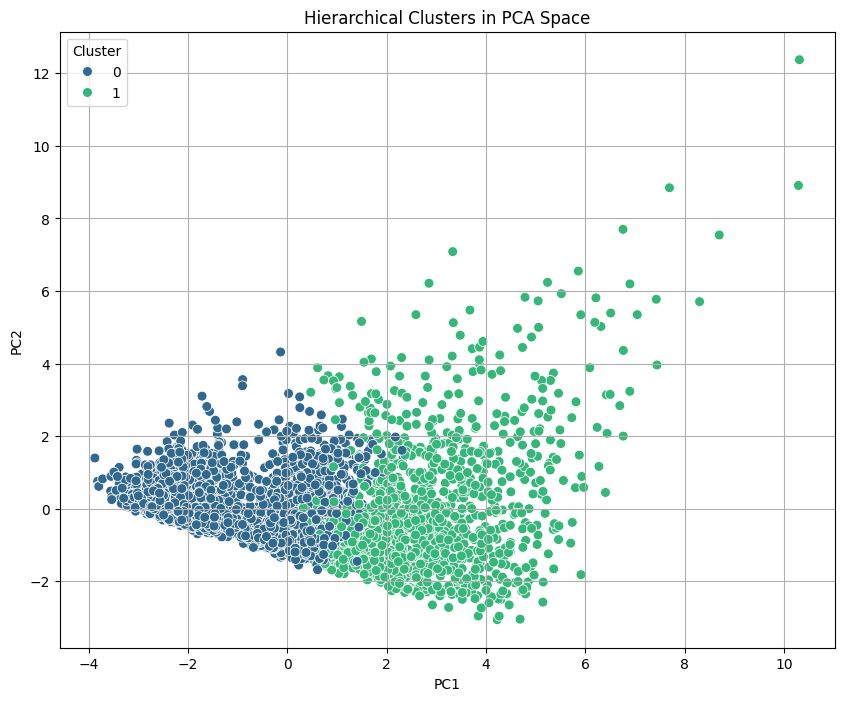


Cross-tabulation of Original Air.Quality and Hierarchical Clusters:
cluster_hc      0    1
Air.Quality           
Good         1584    0
Hazardous       0  396
Moderate     1064  127
Poor          105  724


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the scaled numerical data for clustering (assumes X_cluster_scaled already exists)

silhouette_scores_hc = []
k_values_hc = range(2, 6)

print("\nPerforming Hierarchical Clustering...")

for n_clusters_hc in k_values_hc:
    # NOTE: DO NOT use 'metric' with linkage='ward'
    hc = AgglomerativeClustering(n_clusters=n_clusters_hc, linkage='ward')

    # Fit and predict the clusters
    cluster_labels_hc = hc.fit_predict(X_cluster_scaled)

    # Calculate the silhouette score
    silhouette_avg_hc = silhouette_score(X_cluster_scaled, cluster_labels_hc)
    silhouette_scores_hc.append(silhouette_avg_hc)
    print(f"For n_clusters = {n_clusters_hc} (Hierarchical), the average silhouette_score is: {silhouette_avg_hc:.4f}")

# Find the best number of clusters
best_k_hc = k_values_hc[np.argmax(silhouette_scores_hc)]
print(f"\nBest number of clusters for Hierarchical Clustering based on silhouette score: {best_k_hc}")

# Final clustering using the best number of clusters
hc_best = AgglomerativeClustering(n_clusters=best_k_hc, linkage='ward')
data['cluster_hc'] = hc_best.fit_predict(X_cluster_scaled)

# Print cluster distribution
print("\nHierarchical Cluster distribution:")
print(data['cluster_hc'].value_counts())

# Visualize clusters in PCA space if available
if 'X_pca_df' in locals() and X_pca_df.shape[1] >= 2:
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=X_pca_df.iloc[:, 0], y=X_pca_df.iloc[:, 1], hue=data['cluster_hc'], palette='viridis', s=50)
    plt.title('Hierarchical Clusters in PCA Space')
    plt.xlabel(X_pca_df.columns[0])
    plt.ylabel(X_pca_df.columns[1])
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()
else:
    print("\nNot enough PCA components (at least 2) to visualize hierarchical clusters in 2D PCA space.")

# Compare to the original Air.Quality labels
print("\nCross-tabulation of Original Air.Quality and Hierarchical Clusters:")
print(pd.crosstab(data['Air.Quality'], data['cluster_hc']))


/tmp/ipython-input-26-3627578060.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Cluster')


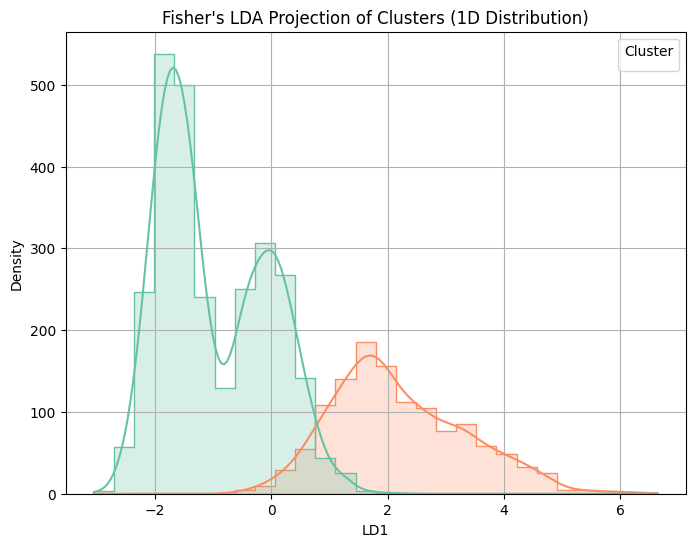

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for creating DataFrame

# Use scaled features and cluster labels (replace with your clustering result)
# Assuming X_cluster_scaled and data['cluster_hc'] (or other cluster column) are available
X = X_cluster_scaled
y = data['cluster_hc']  # or 'cluster' or 'kmedoids_cluster'

# Fit LDA
# The number of components for LDA is min(n_classes - 1, n_features)
# Since we have 2 hierarchical clusters, n_components will be 1.
lda = LinearDiscriminantAnalysis(n_components=min(len(y.unique()) - 1, X.shape[1]))
X_lda = lda.fit_transform(X, y)

# Plot in LDA space
plt.figure(figsize=(8, 6))

if X_lda.shape[1] >= 2:
    # Plot 2D scatter plot if there are at least 2 LDA components
    sns.scatterplot(x=X_lda[:, 0], y=X_lda[:, 1], hue=y, palette='Set2', s=60)
    plt.xlabel('LD1')
    plt.ylabel('LD2')
    plt.title("Fisher's LDA Projection of Clusters (2D)")
elif X_lda.shape[1] == 1:
    # Plot 1D distribution if there is only 1 LDA component
    # We can use a strip plot or a histogram/kde plot along the single dimension
    sns.histplot(x=X_lda[:, 0], hue=y, palette='Set2', kde=True, element='step')
    plt.xlabel('LD1')
    plt.ylabel('Density') # Corrected ylabel
    plt.title("Fisher's LDA Projection of Clusters (1D Distribution)")
else:
    print("LDA did not produce any components to plot.")


plt.grid(True)
plt.legend(title='Cluster')
plt.show()


Mahalanobis Distance Outlier Detection (Threshold = 4.1133)
Number of Mahalanobis outliers detected: 384


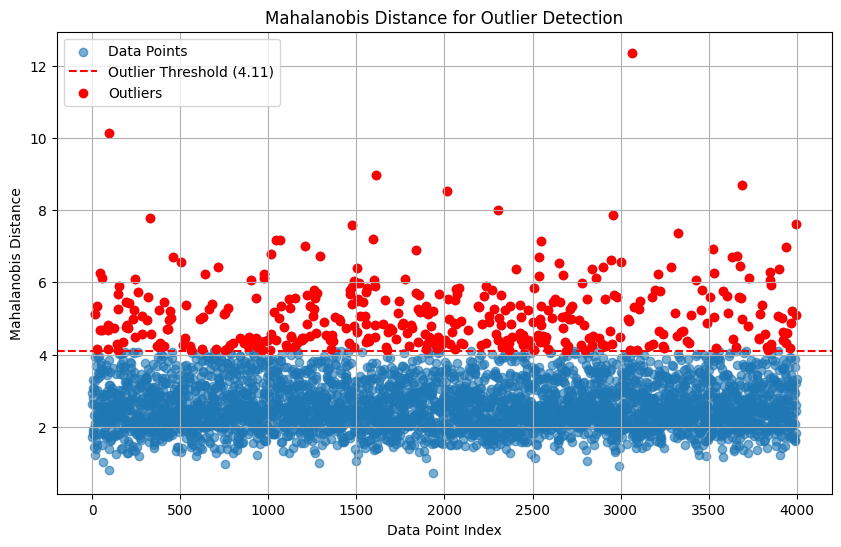

TypeError: cannot convert the series to <class 'float'>

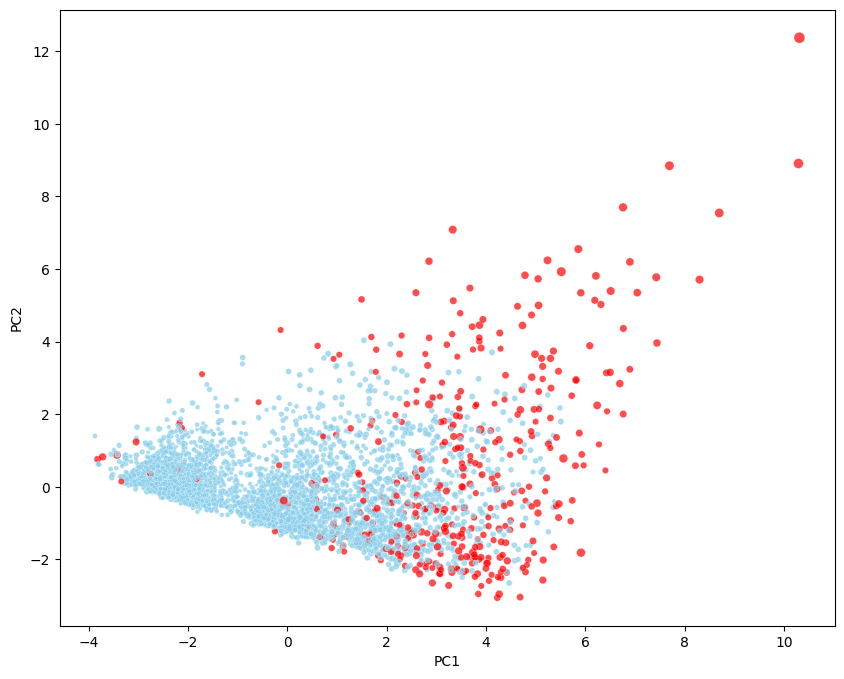

In [ ]:
# prompt: do mahalanobis outlier detection and give plot and outlier number

from scipy.spatial.distance import mahalanobis
from scipy.linalg import inv

# Select numerical columns for Mahalanobis Distance
numerical_data_mahalanobis = data[numerical_cols]

# Calculate the covariance matrix
cov_matrix = numerical_data_mahalanobis.cov()

# Handle potential singularity issues (e.g., using pseudoinverse or adding a small diagonal)
try:
    inv_cov_matrix = inv(cov_matrix)
except np.linalg.LinAlgError:
    print("Covariance matrix is singular. Adding a small diagonal perturbation.")
    cov_matrix_perturbed = cov_matrix + np.eye(cov_matrix.shape[0]) * 1e-6
    inv_cov_matrix = inv(cov_matrix_perturbed)

# Calculate the mean vector
mean_vector = numerical_data_mahalanobis.mean().values

# Calculate Mahalanobis Distance for each data point
mahalanobis_distances = [mahalanobis(x, mean_vector, inv_cov_matrix) for x in numerical_data_mahalanobis.values]

# Add Mahalanobis Distance to the DataFrame
data['mahalanobis_distance'] = mahalanobis_distances

# Define an outlier threshold (e.g., based on chi-squared distribution)
# For p degrees of freedom (number of variables), the Mahalanobis distance squared follows approximately a Chi-squared distribution.
# We use the square root of the chi-squared threshold for the distance itself.
# Let's use a common threshold based on a 95% confidence level (p=0.05).
# Degrees of freedom is the number of variables used (len(numerical_cols))
from scipy.stats import chi2
threshold = np.sqrt(chi2.ppf(0.95, df=len(numerical_cols))) # Using 95% confidence

print(f"\nMahalanobis Distance Outlier Detection (Threshold = {threshold:.4f})")

# Identify outliers
outliers_mahalanobis = data[data['mahalanobis_distance'] > threshold]

print(f"Number of Mahalanobis outliers detected: {len(outliers_mahalanobis)}")

# Plot Mahalanobis distances
plt.figure(figsize=(10, 6))
plt.scatter(data.index, data['mahalanobis_distance'], label='Data Points', alpha=0.6)
plt.axhline(y=threshold, color='r', linestyle='--', label=f'Outlier Threshold ({threshold:.2f})')
plt.scatter(outliers_mahalanobis.index, outliers_mahalanobis['mahalanobis_distance'], color='red', label='Outliers')
plt.xlabel('Data Point Index')
plt.ylabel('Mahalanobis Distance')
plt.title('Mahalanobis Distance for Outlier Detection')
plt.legend()
plt.grid(True)
plt.show()

# You can also visualize in a 2D space, e.g., using the first two PCA components
if 'X_pca_df' in locals() and X_pca_df.shape[1] >= 2:
    plt.figure(figsize=(10, 8))
    # Use the same index for matching mahalanobis distances with PCA data
    pca_with_mahalanobis = X_pca_df.copy()
    pca_with_mahalanobis['mahalanobis_distance'] = data['mahalanobis_distance'] # Assuming data and X_pca_df have same index

    sns.scatterplot(
        x=pca_with_mahalanobis.iloc[:, 0],
        y=pca_with_mahalanobis.iloc[:, 1],
        hue=(pca_with_mahalanobis['mahalanobis_distance'] > threshold),
        palette={False: 'skyblue', True: 'red'},
        s=pca_with_mahalanobis['mahalanobis_distance'] * 5, # Scale marker size by distance
        alpha=0.7
    )
    plt.title('Mahalanobis Outliers in PCA Space (Size proportional to Distance)')
    plt.xlabel(X_pca_df.columns[0])
    plt.ylabel(X_pca_df.columns[1])
    plt.legend(title='Is Outlier (Mahalanobis)')
    plt.grid(True)
    plt.show()
else:
    print("\nNot enough PCA components (at least 2) to visualize Mahalanobis outliers in 2D PCA space.")
